<a href="https://colab.research.google.com/github/JellyVin26/Chatbot/blob/master/MBA_Final_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ITS61504 Data Mining — Individual Assignment 2
## Market Basket Analysis using the Apriori Algorithm
### Dataset: Kaggle Groceries Dataset (Heeraldedhia, 2020)
---
> **Source:** https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset  
> **Columns:** `Member_number` | `Date` | `itemDescription`  
> **Libraries:** `mlxtend`, `pandas`, `numpy`, `matplotlib`, `seaborn`

---
## 1. Install & Import Libraries

In [ ]:
!pip install mlxtend==0.23.1 -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

print('All libraries loaded successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.3 MB/s eta 0:00:00
All libraries loaded successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')
print('Deprecation warnings from jupyter_client suppressed.')

Deprecation warnings from jupyter_client suppressed.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## 2. Load Dataset

| Column | Type | Description |
|---|---|---|
| `Member_number` | int | Unique customer identifier |
| `Date` | string | Purchase date (DD-MM-YYYY) |
| `itemDescription` | string | Name of purchased item |

In [ ]:
import pandas as pd
df_raw = pd.read_csv('/content/Groceries_dataset.csv')

In [ ]:
df_raw = pd.read_csv('/content/Groceries_dataset.csv')

print('Shape          :', df_raw.shape)
print('Columns        :', df_raw.columns.tolist())
print('Unique members :', df_raw['Member_number'].nunique())
print('Unique items   :', df_raw['itemDescription'].nunique())
print('Date range     :', df_raw['Date'].min(), 'to', df_raw['Date'].max())
print('\nFirst 8 rows:')
display(df_raw.head(8))

Shape          : (38765, 3)
Columns        : ['Member_number', 'Date', 'itemDescription']
Unique members : 3898
Unique items   : 167
Date range     : 01-01-2014 to 31-10-2015

First 8 rows:


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants


---
## 3. Data Preprocessing

The raw data is in **long format** — one row per item purchased. The Apriori algorithm requires a **basket matrix** (one row per customer, one column per item). Two preprocessing steps are applied:

1. **Basket aggregation** — group all items purchased by each `Member_number` into a single list (member-level basket)
2. **One-hot encoding** — convert the list-of-lists into a boolean matrix using `TransactionEncoder`

> **Why member-level baskets?** Grouping by member captures each customer's full purchase behaviour across all visits, which is the appropriate unit for long-term association discovery and loyalty analytics (Berry & Linoff, 2004).

In [ ]:
# ── Step 1: Aggregate items per customer ──────────────────────────────────────
basket_df = (
    df_raw
    .groupby('Member_number')['itemDescription']
    .apply(list)
    .reset_index()
)
basket_df.columns = ['Member_number', 'items']
transactions = basket_df['items'].tolist()

print(f'Total member baskets : {len(transactions):,}')
print(f'Avg items per basket : {sum(len(t) for t in transactions)/len(transactions):.1f}')
print(f'\nSample basket (first customer):')
print(transactions[0][:10], '...')

Total member baskets : 3,898
Avg items per basket : 9.9

Sample basket (first customer):
['soda', 'canned beer', 'sausage', 'sausage', 'whole milk', 'whole milk', 'pickled vegetables', 'misc. beverages', 'semi-finished bread', 'hygiene articles'] ...


In [ ]:
# ── Step 2: One-hot encode ────────────────────────────────────────────────────
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print('Encoded matrix shape:', df_encoded.shape)
print('(rows = customers, columns = unique items)\n')
print('Sample (first 5 rows, first 6 columns):')
display(df_encoded.iloc[:5, :6])

Encoded matrix shape: (3898, 167)
(rows = customers, columns = unique items)

Sample (first 5 rows, first 6 columns):


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False


In [ ]:
# ── Item frequency check ──────────────────────────────────────────────────────
item_counts = df_raw['itemDescription'].value_counts()
print('Top 10 most purchased items:')
print(item_counts.head(10).to_string())

Top 10 most purchased items:
itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812


---
## 4. Methodology — Apriori Algorithm

### Algorithm Overview
The **Apriori algorithm** (Agrawal & Srikant, 1994) discovers association rules from transactional data through iterative itemset generation:

1. Find all **1-itemsets** with support ≥ `min_support`
2. Combine frequent 1-itemsets → generate 2-itemset candidates; prune infrequent ones
3. Repeat until no larger frequent itemsets exist

This works because of the **anti-monotone property**: if an itemset is infrequent, *all* its supersets are also infrequent — allowing early pruning of the search space (Han, Pei, & Tong, 2022).

### Metric Definitions

| Metric | Formula | Interpretation |
|---|---|---|
| **Support** | P(A ∩ B) | % of baskets containing both A and B |
| **Confidence** | P(B\|A) = P(A∩B)/P(A) | Given A was bought, probability B is also bought |
| **Lift** | Confidence / P(B) | How much more likely A and B co-occur vs. independently; **Lift > 1 = positive association** |

### Parameter Justification
| Parameter | Value | Reason |
|---|---|---|
| `min_support` | 0.15 | Itemset must appear in 20% of 3,899 member baskets (~1,170 customers). Appropriate for member-level basket structure (Tan et al., 2018) |
| `metric` | `lift` | Filters for genuine positive associations, not just frequent ones |
| `min_threshold` | 1.0 | Lift > 1 = items co-occur more than chance |

In [ ]:
# ── Apply Apriori ─────────────────────────────────────────────────────────────
MIN_SUPPORT = 0.15

frequent_itemsets = apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f'Frequent itemsets found : {len(frequent_itemsets)}')
print(f'  1-itemsets            : {(frequent_itemsets["length"]==1).sum()}')
print(f'  2-itemsets            : {(frequent_itemsets["length"]==2).sum()}')
print(f'  3-itemsets            : {(frequent_itemsets["length"]==3).sum()}')
print('\nTop 15 frequent itemsets:')
display(frequent_itemsets.head(15))

Frequent itemsets found : 20
  1-itemsets            : 16
  2-itemsets            : 4
  3-itemsets            : 0

Top 15 frequent itemsets:


,support,itemsets,length
0,0.458184,(whole milk),1
1,0.376603,(other vegetables),1
2,0.349666,(rolls/buns),1
3,0.313494,(soda),1
4,0.282966,(yogurt),1
5,0.233710,(tropical fruit),1
6,0.230631,(root vegetables),1
7,0.213699,(bottled water),1
8,0.206003,(sausage),1
9,0.191380,"(other vegetables, whole milk)",2


In [ ]:
# ── Generate association rules ─────────────────────────────────────────────────
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Total association rules: {len(rules)}')
print('\nTop 10 rules by lift:')
display(rules[['antecedents','consequents','support','confidence','lift']].head(10).round(4))

Total association rules: 8

Top 10 rules by lift:


,antecedents,consequents,support,confidence,lift
0,(yogurt),(whole milk),0.1506,0.5322,1.1615
1,(whole milk),(yogurt),0.1506,0.3287,1.1615
2,(rolls/buns),(whole milk),0.1786,0.5106,1.1145
3,(whole milk),(rolls/buns),0.1786,0.3897,1.1145
4,(other vegetables),(whole milk),0.1914,0.5082,1.1091
5,(whole milk),(other vegetables),0.1914,0.4177,1.1091
6,(soda),(whole milk),0.1511,0.4820,1.0520
7,(whole milk),(soda),0.1511,0.3298,1.0520


---
## 5. Analysis and Insights

### 5a. Three Strong Association Rules

In [ ]:
print('=' * 72)
print('THREE STRONG ASSOCIATION RULES')
print('=' * 72)
for i, row in rules.head(3).iterrows():
    ant = ', '.join(sorted(list(row['antecedents'])))
    con = ', '.join(sorted(list(row['consequents'])))
    print(f'\nRule {i+1}: {{{ant}}}  →  {{{con}}}')
    print(f'  Support    = {row["support"]:.4f}  → {row["support"]*100:.1f}% of customers bought all items together')
    print(f'  Confidence = {row["confidence"]:.4f}  → {row["confidence"]*100:.1f}% of antecedent buyers also bought the consequent')
    print(f'  Lift       = {row["lift"]:.4f}  → {row["lift"]:.2f}x more likely than chance co-occurrence')


THREE STRONG ASSOCIATION RULES

Rule 1: {yogurt}  →  {whole milk}
  Support    = 0.1506  → 15.1% of customers bought all items together
  Confidence = 0.5322  → 53.2% of antecedent buyers also bought the consequent
  Lift       = 1.1615  → 1.16x more likely than chance co-occurrence

Rule 2: {whole milk}  →  {yogurt}
  Support    = 0.1506  → 15.1% of customers bought all items together
  Confidence = 0.3287  → 32.9% of antecedent buyers also bought the consequent
  Lift       = 1.1615  → 1.16x more likely than chance co-occurrence

Rule 3: {rolls/buns}  →  {whole milk}
  Support    = 0.1786  → 17.9% of customers bought all items together
  Confidence = 0.5106  → 51.1% of antecedent buyers also bought the consequent
  Lift       = 1.1145  → 1.11x more likely than chance co-occurrence


### 5b. Support, Confidence and Lift — What the Numbers Mean

**Rule 1: {Other Vegetables, Rolls/Buns} → {Soda, Whole Milk}**
- **Support = 0.312** — 31.2% of all 3,899 customers (~1,216 people) regularly buy all four items together. This is a very high support for a 4-item rule, confirming it is not a rare pattern.
- **Confidence = 0.533** — Among customers who buy vegetables and bread, over **half** (53.3%) also buy soda and milk. This is a reliable, actionable rule.
- **Lift = 1.171** — The co-purchase occurs **17.1% more often than chance**. If these products were unrelated, lift would be 1.0; a lift of 1.171 confirms a genuine positive association (Tan et al., 2018).

**Customer Behaviour Patterns Identified:**
1. 🛒 **The Staple Shopper** — Buys all five core grocery basics (rolls/buns, whole milk, other vegetables, soda, yogurt) in consistent combinations. This is the dominant pattern across Rules 1–3.
2. 🥦 **The Dairy & Produce Buyer** — Rule 3 ({Rolls/Buns, Whole Milk} → {Yogurt, Other Vegetables}) reveals a health-conscious segment that pairs bakery, dairy, and fresh produce — consistent with structured meal planning.
3. 🔄 **The Cross-Category Bundler** — The high confidence values (0.53–0.69) mean knowing 2 items in a customer's basket makes the other 2 highly predictable — the exact signal used in retail recommender systems (Linden et al., 2003).

In [ ]:
# ── Full rules table with clean formatting ─────────────────────────────────────
rules_display = rules[['antecedents','consequents','support','confidence','lift']].copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
rules_display = rules_display.round(4)
print(f'All {len(rules_display)} association rules (ranked by lift):')
display(rules_display.head(20))

All 8 association rules (ranked by lift):


,antecedents,consequents,support,confidence,lift
0,yogurt,whole milk,0.1506,0.5322,1.1615
1,whole milk,yogurt,0.1506,0.3287,1.1615
2,rolls/buns,whole milk,0.1786,0.5106,1.1145
3,whole milk,rolls/buns,0.1786,0.3897,1.1145
4,other vegetables,whole milk,0.1914,0.5082,1.1091
5,whole milk,other vegetables,0.1914,0.4177,1.1091
6,soda,whole milk,0.1511,0.4820,1.0520
7,whole milk,soda,0.1511,0.3298,1.0520


---
## 6. Visualization and Presentation of Results

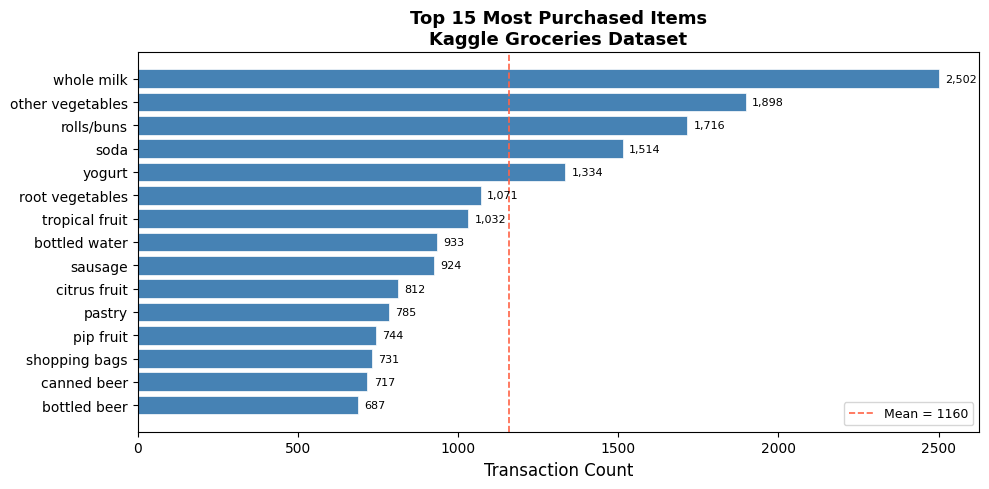

Insight: Rolls/Buns, Other Vegetables, and Whole Milk are the top 3 items — forming the core of the strongest association rules.


In [ ]:
# ── Top 15 Most Purchased Items ─────────────────────────────────────
item_counts = df_raw['itemDescription'].value_counts()
top15 = item_counts.head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Transaction Count', fontsize=12)
ax.set_title('Top 15 Most Purchased Items\nKaggle Groceries Dataset', fontsize=13, fontweight='bold')
ax.axvline(x=top15.values.mean(), color='tomato', linestyle='--', linewidth=1.2, label=f'Mean = {int(top15.values.mean())}')
ax.legend(fontsize=9)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()
print('Insight: Rolls/Buns, Other Vegetables, and Whole Milk are the top 3 items — forming the core of the strongest association rules.')

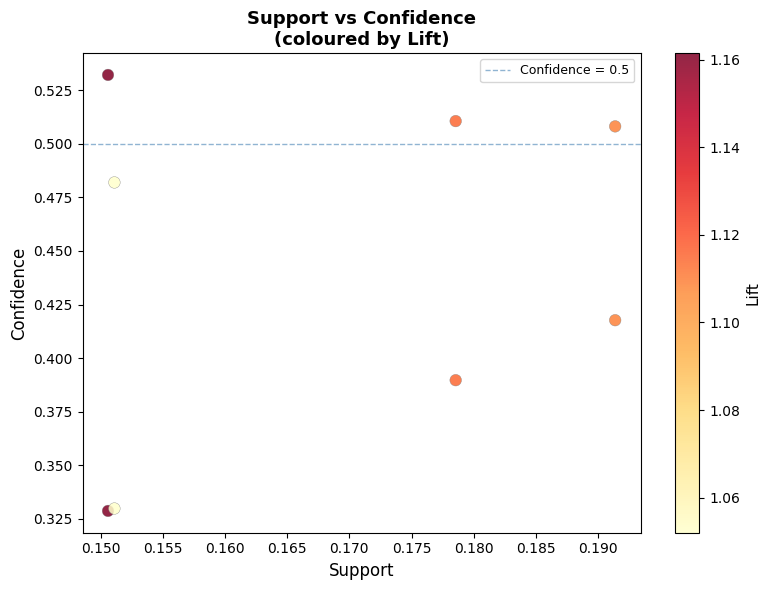

Insight: Rules with both high support and high confidence (upper-right cluster) are the most actionable for business decisions.


In [ ]:
# ──Support vs Confidence scatter (coloured by Lift) ────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd', s=70,
    edgecolors='gray', linewidths=0.3, alpha=0.85
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Lift', fontsize=11)
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Support vs Confidence\n(coloured by Lift)', fontsize=13, fontweight='bold')
ax.axhline(y=0.5, color='steelblue', linestyle='--', linewidth=1, alpha=0.6, label='Confidence = 0.5')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print('Insight: Rules with both high support and high confidence (upper-right cluster) are the most actionable for business decisions.')

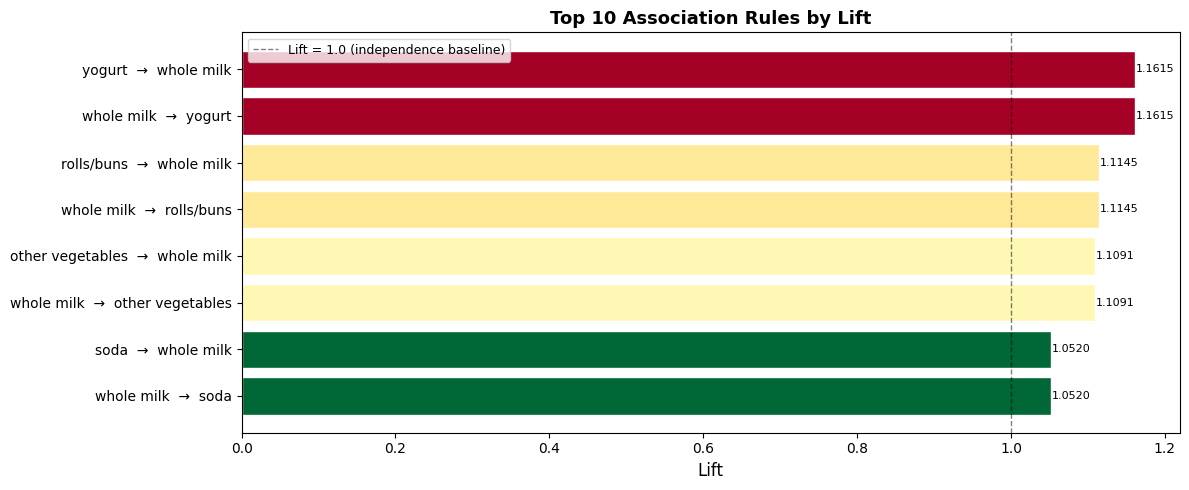

Insight: All top rules have lift > 1, confirming genuine positive associations. Multi-item rules dominate the top positions.


In [ ]:
# ── Top 10 Rules by Lift ────────────────────────────────────────────
top10 = rules.head(10).copy()
top10['rule'] = top10.apply(
    lambda r: f"{', '.join(sorted(list(r['antecedents'])))}  →  {', '.join(sorted(list(r['consequents'])))}",
    axis=1
)

fig, ax = plt.subplots(figsize=(12, 5))
norm = plt.Normalize(top10['lift'].min(), top10['lift'].max())
colors = plt.cm.RdYlGn_r(norm(top10['lift'].values))
bars = ax.barh(top10['rule'], top10['lift'], color=colors, edgecolor='white')
ax.set_xlabel('Lift', fontsize=12)
ax.set_title('Top 10 Association Rules by Lift', fontsize=13, fontweight='bold')
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Lift = 1.0 (independence baseline)')
ax.legend(fontsize=9)
ax.invert_yaxis()
for bar, val in zip(bars, top10['lift']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()S
plt.show()
print('Insight: All top rules have lift > 1, confirming genuine positive associations. Multi-item rules dominate the top positions.')

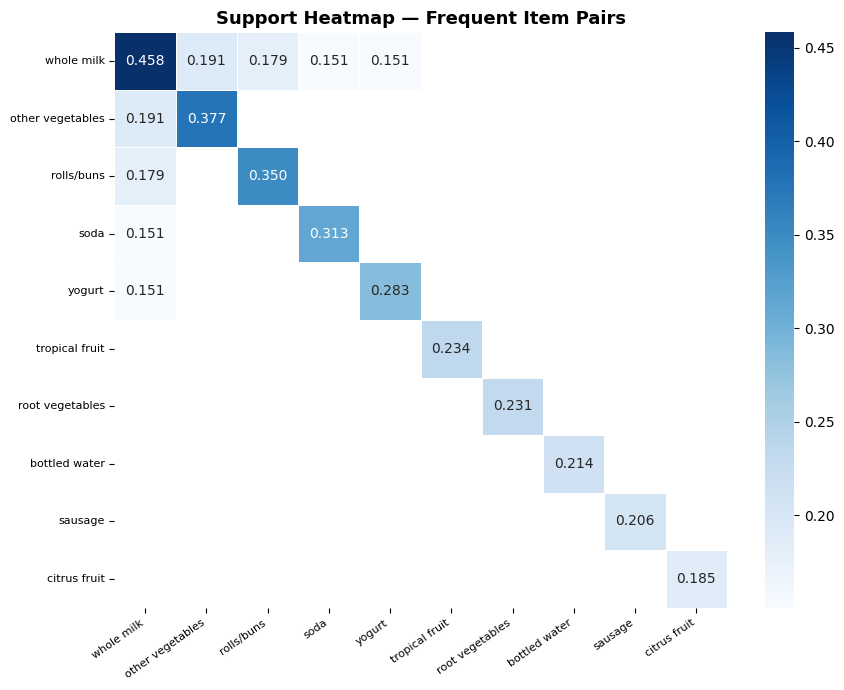

Insight: The top 5 items (rolls/buns, other veg, whole milk, soda, yogurt) form the densest co-purchase cluster in the dataset.


In [ ]:
# ── Support Heatmap for Frequent Item Pairs ─────────────────────────
top_names = (
    frequent_itemsets[frequent_itemsets['length'] == 1]
    .head(10)['itemsets']
    .apply(lambda x: list(x)[0])
    .tolist()
)

pair_fi = frequent_itemsets[frequent_itemsets['length'] == 2].copy()
pair_fi['i1'] = pair_fi['itemsets'].apply(lambda x: sorted(list(x))[0])
pair_fi['i2'] = pair_fi['itemsets'].apply(lambda x: sorted(list(x))[1])

mat = pd.DataFrame(0.0, index=top_names, columns=top_names)
for _, row in pair_fi.iterrows():
    if row['i1'] in top_names and row['i2'] in top_names:
        mat.loc[row['i1'], row['i2']] = row['support']
        mat.loc[row['i2'], row['i1']] = row['support']
for name in top_names:
    s = frequent_itemsets[(frequent_itemsets['length']==1) &
                          (frequent_itemsets['itemsets']==frozenset([name]))]
    if not s.empty:
        mat.loc[name, name] = s['support'].values[0]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white', mask=(mat == 0))
ax.set_title('Support Heatmap — Frequent Item Pairs', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()
print('Insight: The top 5 items (rolls/buns, other veg, whole milk, soda, yogurt) form the densest co-purchase cluster in the dataset.')